<a href="https://colab.research.google.com/github/chrisnelsonlab/BMEG4623/blob/master/6_Transport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src=https://brand.uark.edu/_resources/images/UA_Logo_Horizontal.jpg width="400" height="96">

####BMEG 4623 - Tranposrt phenomenon in biomedical engineering
####For more information, check out the Nelson lab for Therapeutic Genome Engineering (https://nelsonlab.uark.edu/)

For image credits, see the linked URL

# Pharmacokinetics

The goal for today is to introduce transport phenomenon and the driving force behind transport processes

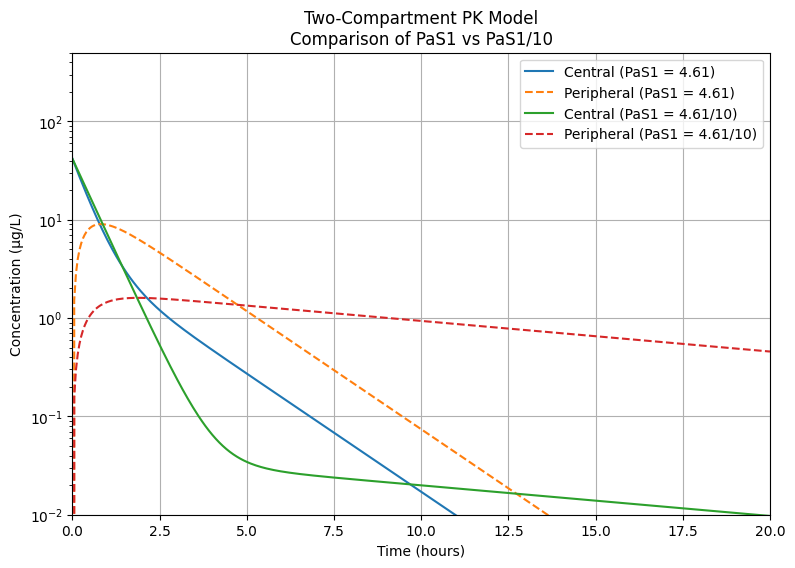

In [1]:
# Two-compartment PK model in Python (Google Colab version)
# Plots two versions of PaS1: original and 10x lower

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameter sets
# -----------------------------
PaS1_values = {
    "PaS1 = 4.61": 4.61,
    "PaS1 = 4.61/10": 4.61/10
}

Vc = 12.0       # L central volume
Vp = 5.9        # L peripheral volume
Qb = 20.76      # L/hr renal blood flow
PhiAcp = 0.939  # partition coefficient

# initial conditions
u0 = 500000 / 12000   # central concentration
v0 = 0                # peripheral concentration

# time grid
t = sp.symbols('t', real=True, positive=True)
time = np.linspace(0, 20, 400)

# Storage for plotting
results = {}

# -----------------------------
# Loop over the two PaS1 versions
# -----------------------------
for label, PaS1 in PaS1_values.items():

    # Rate constants
    kcp = PaS1 / Vc
    kpc = PhiAcp * PaS1 / Vp
    kel = Qb / Vc

    # Symbols
    u = sp.Function('u')(t)
    v = sp.Function('v')(t)

    # ODE system
    ode1 = sp.diff(u, t) - (-(kcp + kel) * u + kpc * v)
    ode2 = sp.diff(v, t) - (kcp * u - kpc * v)

    # Initial conditions
    ics = {u.subs(t,0): u0, v.subs(t,0): v0}

    # Solve
    sol = sp.dsolve([ode1, ode2], ics=ics)
    uSol = sp.lambdify(t, sol[0].rhs, 'numpy')
    vSol = sp.lambdify(t, sol[1].rhs, 'numpy')

    # store solutions
    results[label] = {
        "u": uSol(time),
        "v": vSol(time) * (Vc / Vp)   # scale peripheral compartment
    }

# -----------------------------
# Plotting
# -----------------------------
plt.figure(figsize=(9,6))

# plot both PaS1 versions
for label in results:
    plt.plot(time, results[label]["u"], label=f"Central ({label})")
    plt.plot(time, results[label]["v"], '--', label=f"Peripheral ({label})")

plt.yscale('log')
plt.xlim(0, 20)
plt.ylim(0.01, 500)
plt.grid(True)
plt.legend()
plt.xlabel("Time (hours)")
plt.ylabel("Concentration (µg/L)")
plt.title("Two-Compartment PK Model\nComparison of PaS1 vs PaS1/10")
plt.show()


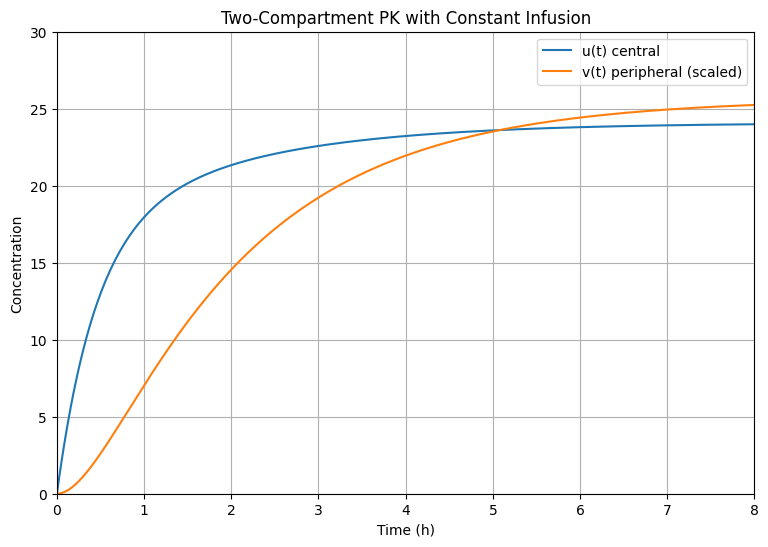

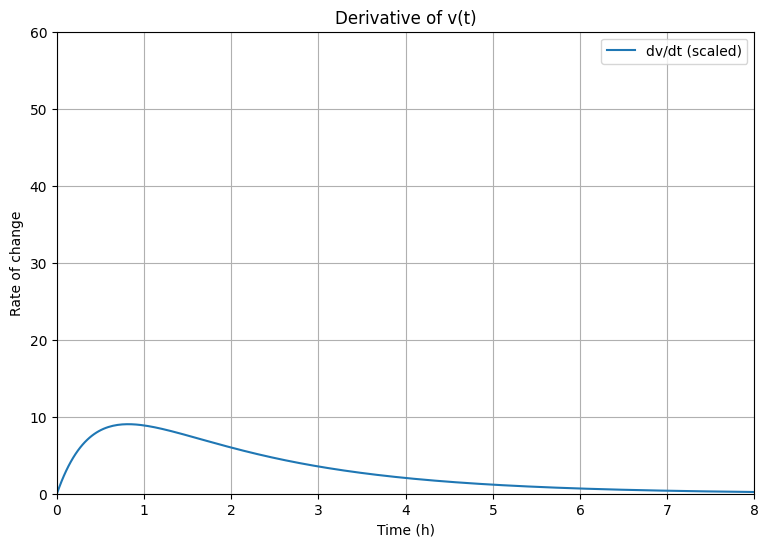

In [2]:
# Two-compartment PK model with constant infusion
# Symbolic solution and derivatives
# Cleaned version of the MATLAB code

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
PaS1 = 4.61  # L/hr permeability × surface area
Vc = 12.0
Vp = 5.9
Qb = 20.76
PhiAcp = 0.939

# constant infusion (mg/hr)
w_t = 500

# rate constants
k1 = PaS1 / Vc               # central → peripheral
k3 = PhiAcp * PaS1 / Vp      # peripheral → central
k2 = Qb / Vc                 # elimination

# -----------------------------
# Define symbolic system
# -----------------------------
t = sp.symbols('t', real=True, positive=True)
u = sp.Function('u')(t)    # central compartment
v = sp.Function('v')(t)    # peripheral compartment

ode1 = sp.diff(u, t) - (w_t/Vc - (k1+k2)*u + k3*v)
ode2 = sp.diff(v, t) - (k1*u - k3*v)

# -----------------------------
# Solve with initial conditions
# -----------------------------
ics = {u.subs(t,0): 0, v.subs(t,0): 0}
sol = sp.dsolve([ode1, ode2], ics=ics)

u_sol = sol[0].rhs
v_sol = sol[1].rhs

# -----------------------------
# Derivatives (cleaned)
# -----------------------------
u_prime = sp.diff(u_sol, t)
v_prime = sp.diff(v_sol, t)

# lambdify everything for plotting
u_fun = sp.lambdify(t, u_sol, "numpy")
v_fun = sp.lambdify(t, v_sol, "numpy")

u_prime_fun = sp.lambdify(t, u_prime, "numpy")
v_prime_fun = sp.lambdify(t, v_prime, "numpy")

# -----------------------------
# Time grid
# -----------------------------
T = np.linspace(0, 8, 300)

# -----------------------------
# Plot: u and v
# -----------------------------
plt.figure(figsize=(9,6))
plt.plot(T, u_fun(T), label="u(t) central")
plt.plot(T, v_fun(T)*(Vc/Vp), label="v(t) peripheral (scaled)")

plt.grid(True)
plt.xlabel("Time (h)")
plt.ylabel("Concentration")
plt.xlim(0, 8)
plt.ylim(0, 30)
plt.title("Two-Compartment PK with Constant Infusion")
plt.legend()
plt.show()

# -----------------------------
# Plot derivative of v(t) *only*
# -----------------------------
plt.figure(figsize=(9,6))
plt.plot(T, v_prime_fun(T)*(Vc/Vp), label="dv/dt (scaled)")

plt.grid(True)
plt.xlabel("Time (h)")
plt.ylabel("Rate of change")
plt.xlim(0, 8)
plt.ylim(0, 60)
plt.title("Derivative of v(t)")
plt.legend()
plt.show()

[-0.02954764 -0.15459158]
[-0.00505887 -0.80778323]


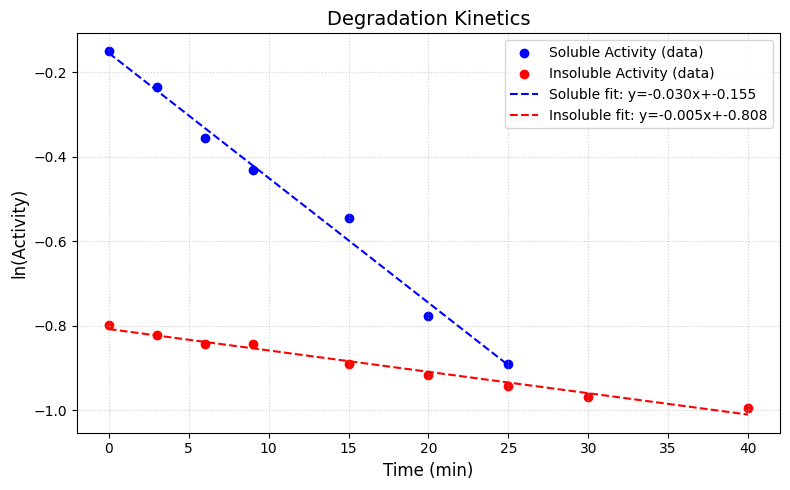

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create an array for data
Time_s = np.array([0, 180, 360, 540, 900, 1200, 1500, 1800, 2400])
Time_min = Time_s/60

Sol_Act = np.array([0.86, 0.79, 0.7, 0.65, 0.58, 0.46, 0.41])
InSol_Act = np.array([0.45, 0.44, 0.43, 0.43, 0.41, 0.4, 0.39, 0.38, 0.37])

ln_Sol_Act = np.log(Sol_Act)
ln_Insol_Act = np.log(InSol_Act)

#Make bestfit lines
fit_sol = np.polyfit(Time_min[:len(ln_Sol_Act)], ln_Sol_Act, 1)
fit_insol = np.polyfit(Time_min, ln_Insol_Act, 1)
print(fit_sol)
print(fit_insol)

# Generate best-fit line values
sol_fit_line = np.polyval(fit_sol, Time_min[:len(ln_Sol_Act)])
insol_fit_line = np.polyval(fit_insol, Time_min)


plt.figure(figsize=(8, 5))
plt.scatter(Time_min[:len(ln_Sol_Act)], ln_Sol_Act, color='blue', label='Soluble Activity (data)')
plt.scatter(Time_min, ln_Insol_Act, color='red', label='Insoluble Activity (data)')
plt.plot(Time_min[:len(ln_Sol_Act)], sol_fit_line, color='blue', linestyle='--', label=f'Soluble fit: y={fit_sol[0]:.3f}x+{fit_sol[1]:.3f}')
plt.plot(Time_min, insol_fit_line, color='red', linestyle='--', label=f'Insoluble fit: y={fit_insol[0]:.3f}x+{fit_insol[1]:.3f}')

# Labels and style
plt.xlabel('Time (min)', fontsize=12)
plt.ylabel('ln(Activity)', fontsize=12)
plt.title('Degradation Kinetics', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()